In [2]:
# ============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Sentiment Analysis pada Tweet
# Kelompok: NaLapPro
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Setting style visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - SENTIMENT ANALYSIS")
print("="*60)

📊 EXPLORATORY DATA ANALYSIS - SENTIMENT ANALYSIS


In [3]:
# ============================================
# 1. LOAD DATA
# ============================================

# Load dataset
df = pd.read_csv('/Users/macbookair/Documents/NLP/Sentiment-analysis/data/tweet.csv')  # Sesuaikan path

print(f"\n📦 Dataset Shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")

# Tampilkan 5 data pertama
print("\n👀 5 Data Pertama:")
df.head()


📦 Dataset Shape: (1815, 3)

📋 Columns: ['Unnamed: 0', 'sentimen', 'tweet']

👀 5 Data Pertama:


,Unnamed: 0,sentimen,tweet
0,0,negatif,Kata @prabowo Indonesia tidak dihargai bangsa ...
1,1,netral,"Batuan Langka, Tasbih Jokowi Hadiah dari Habib..."
2,2,netral,"Di era Jokowi, ekonomi Indonesia semakin baik...."
3,3,positif,"Bagi Sumatera Selatan, Asian Games berdampak p..."
4,4,negatif,Negara kita ngutang buat bngun infrastruktur y...


In [4]:
# ============================================
# 2. INFORMASI DASAR DATASET
# ============================================

print("\n" + "="*60)
print("📌 INFORMASI DASAR DATASET")
print("="*60)

# Info dataset
print("\n📊 Info Dataset:")
df.info()

# Statistik deskriptif untuk kolom numerik
print("\n📈 Statistik Deskriptif:")
df.describe()

# Statistik untuk kolom kategorikal
print("\n🏷️ Statistik Kolom Kategorikal:")
df.describe(include=['O'])


📌 INFORMASI DASAR DATASET

📊 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815 entries, 0 to 1814
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1815 non-null   int64 
 1   sentimen    1815 non-null   object
 2   tweet       1815 non-null   object
dtypes: int64(1), object(2)
memory usage: 42.7+ KB

📈 Statistik Deskriptif:

🏷️ Statistik Kolom Kategorikal:


,sentimen,tweet
count,1815,1815
unique,3,1815
top,positif,Kata @prabowo Indonesia tidak dihargai bangsa ...
freq,612,1



🔍 CEK MISSING VALUES

📊 Missing Values per Kolom:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

✅ Tidak ada missing values dalam dataset!


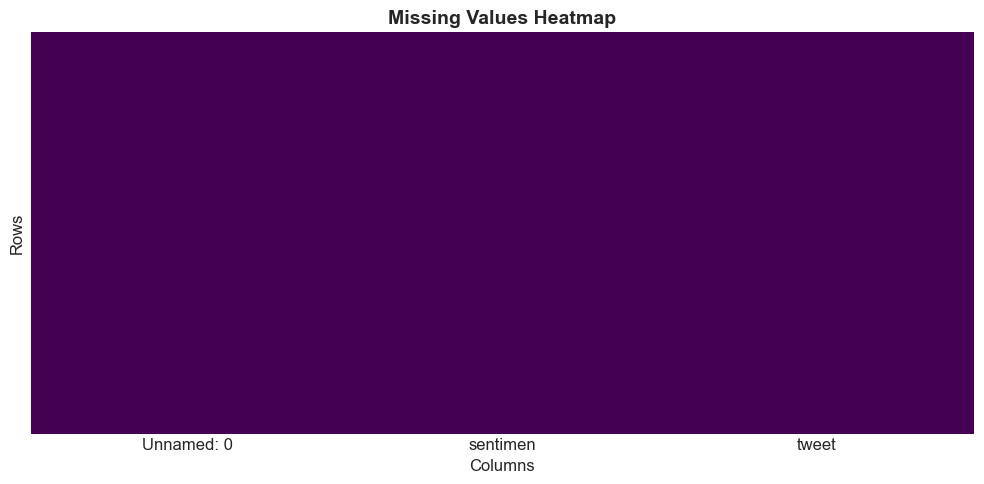

In [5]:
# ============================================
# 3. CEK MISSING VALUES
# ============================================

print("\n" + "="*60)
print("🔍 CEK MISSING VALUES")
print("="*60)

# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
})

print("\n📊 Missing Values per Kolom:")
print(missing_df[missing_df['Missing Values'] > 0])

if missing.sum() == 0:
    print("\n✅ Tidak ada missing values dalam dataset!")
else:
    print(f"\n⚠️ Ditemukan {missing.sum()} missing values")

# Visualisasi missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontweight='bold', fontsize=14)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

In [6]:
# ============================================
# 4. CEK DATA DUPLIKAT
# ============================================

print("\n" + "="*60)
print("🔄 CEK DATA DUPLIKAT")
print("="*60)

# Cek duplikat berdasarkan tweet
duplicate_count = df.duplicated(subset=['tweet']).sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"\n📊 Total data duplikat: {duplicate_count} baris ({duplicate_pct:.2f}%)")

if duplicate_count > 0:
    print("\n🔍 Contoh data duplikat:")
    duplicates = df[df.duplicated(subset=['tweet'], keep=False)]
    print(duplicates.sort_values('tweet').head(10))
else:
    print("\n✅ Tidak ada data duplikat dalam dataset!")


🔄 CEK DATA DUPLIKAT

📊 Total data duplikat: 0 baris (0.00%)

✅ Tidak ada data duplikat dalam dataset!



📊 DISTRIBUSI LABEL SENTIMEN

📋 Distribusi Sentimen:
          Jumlah  Persentase (%)
sentimen                        
positif      612           33.72
netral       607           33.44
negatif      596           32.84


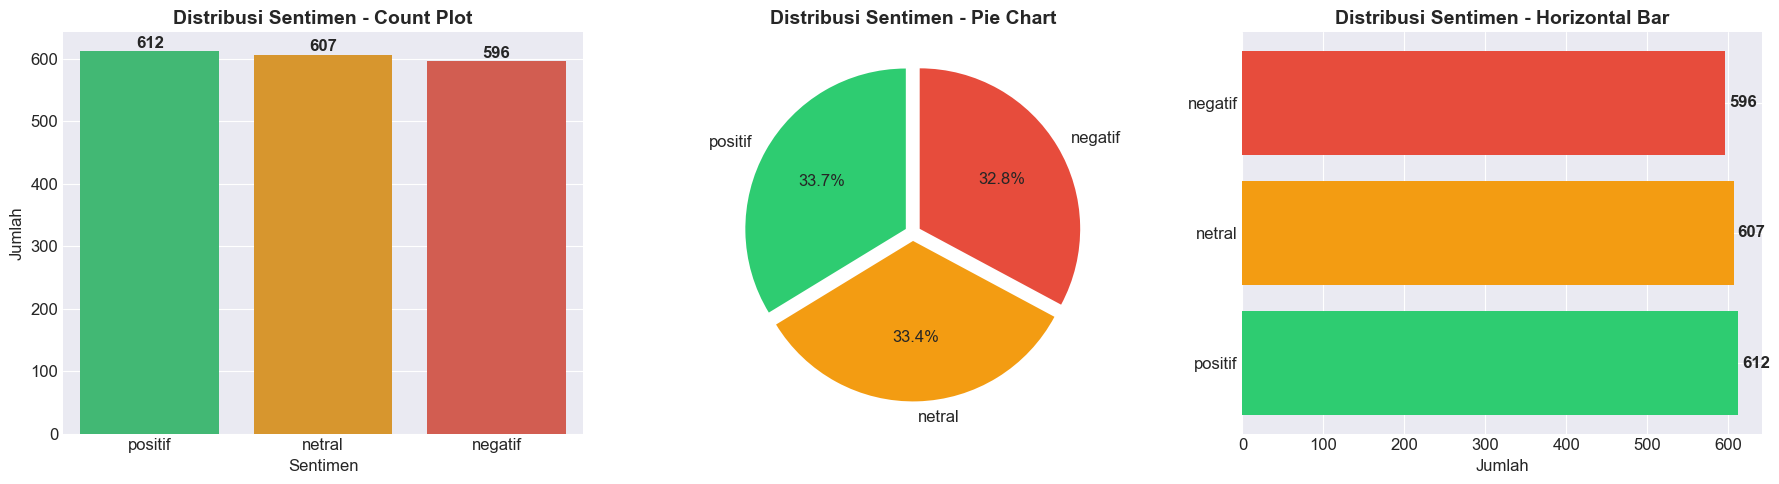

In [7]:
# ============================================
# 5. DISTRIBUSI LABEL SENTIMEN
# ============================================

print("\n" + "="*60)
print("📊 DISTRIBUSI LABEL SENTIMEN")
print("="*60)

# Hitung distribusi
sentimen_counts = df['sentimen'].value_counts()
sentimen_pct = (sentimen_counts / len(df)) * 100

# Tabel distribusi
dist_df = pd.DataFrame({
    'Jumlah': sentimen_counts,
    'Persentase (%)': sentimen_pct.round(2)
})
print("\n📋 Distribusi Sentimen:")
print(dist_df)

# Visualisasi 1: Count Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot
sns.countplot(data=df, x='sentimen', ax=axes[0], 
              order=['positif', 'netral', 'negatif'],
              palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Distribusi Sentimen - Count Plot', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(sentimen_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(sentimen_counts.values, labels=sentimen_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Distribusi Sentimen - Pie Chart', fontweight='bold', fontsize=14)

# Horizontal bar
axes[2].barh(sentimen_counts.index, sentimen_counts.values, color=colors)
axes[2].set_title('Distribusi Sentimen - Horizontal Bar', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Jumlah')
for i, v in enumerate(sentimen_counts.values):
    axes[2].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


📏 ANALISIS PANJANG TWEET

📊 Statistik Panjang Tweet (karakter):
count    1815.000000
mean      194.669972
std        75.533506
min        27.000000
25%       134.000000
50%       200.000000
75%       258.000000
max       668.000000
Name: tweet_length, dtype: float64

📊 Statistik Jumlah Kata:
count    1815.000000
mean       24.934435
std        10.820302
min         5.000000
25%        15.000000
50%        24.000000
75%        34.000000
max        53.000000
Name: word_count, dtype: float64


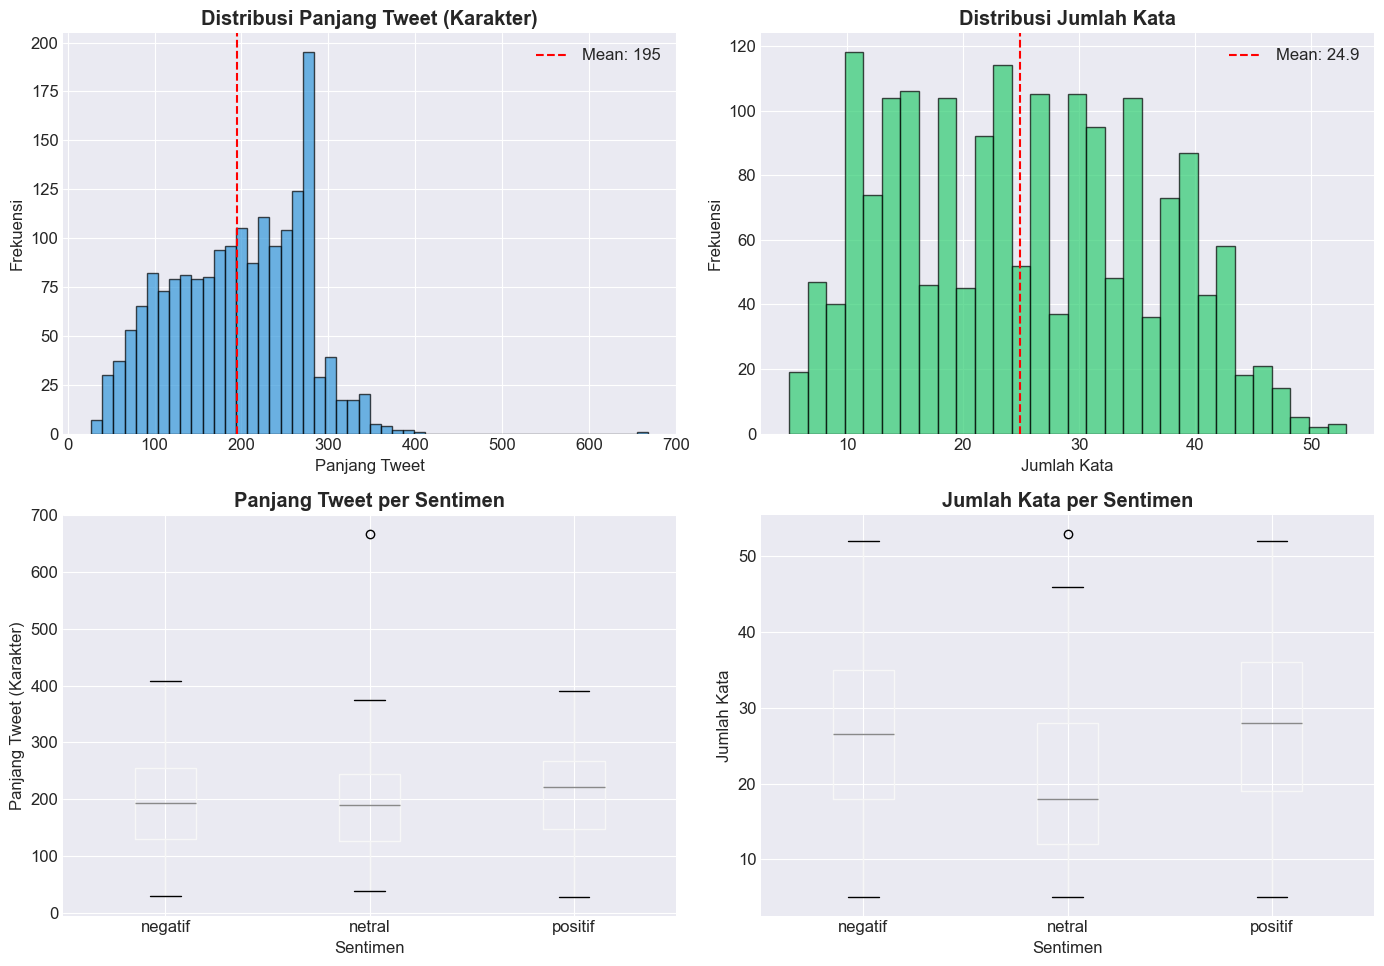


📊 Rata-rata Panjang Tweet per Sentimen:
            mean  median  max  min
sentimen                          
negatif   189.28   193.0  408   30
netral    187.23   189.0  668   39
positif   207.30   221.5  390   27

📊 Rata-rata Jumlah Kata per Sentimen:
           mean  median  max  min
sentimen                         
negatif   26.81    26.5   52    5
netral    20.39    18.0   53    5
positif   27.62    28.0   52    5


In [8]:
# ============================================
# 6. ANALISIS PANJANG TWEET
# ============================================

print("\n" + "="*60)
print("📏 ANALISIS PANJANG TWEET")
print("="*60)

# Hitung panjang tweet
df['tweet_length'] = df['tweet'].str.len()
df['word_count'] = df['tweet'].str.split().str.len()

# Statistik panjang tweet
print("\n📊 Statistik Panjang Tweet (karakter):")
print(df['tweet_length'].describe())

print("\n📊 Statistik Jumlah Kata:")
print(df['word_count'].describe())

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram panjang tweet
axes[0,0].hist(df['tweet_length'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['tweet_length'].mean(), color='red', linestyle='--', 
                  label=f"Mean: {df['tweet_length'].mean():.0f}")
axes[0,0].set_title('Distribusi Panjang Tweet (Karakter)', fontweight='bold')
axes[0,0].set_xlabel('Panjang Tweet')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].legend()

# Histogram jumlah kata
axes[0,1].hist(df['word_count'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0,1].axvline(df['word_count'].mean(), color='red', linestyle='--',
                  label=f"Mean: {df['word_count'].mean():.1f}")
axes[0,1].set_title('Distribusi Jumlah Kata', fontweight='bold')
axes[0,1].set_xlabel('Jumlah Kata')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend()

# Boxplot panjang tweet per sentimen
df.boxplot(column='tweet_length', by='sentimen', ax=axes[1,0])
axes[1,0].set_title('Panjang Tweet per Sentimen', fontweight='bold')
axes[1,0].set_xlabel('Sentimen')
axes[1,0].set_ylabel('Panjang Tweet (Karakter)')

# Boxplot jumlah kata per sentimen
df.boxplot(column='word_count', by='sentimen', ax=axes[1,1])
axes[1,1].set_title('Jumlah Kata per Sentimen', fontweight='bold')
axes[1,1].set_xlabel('Sentimen')
axes[1,1].set_ylabel('Jumlah Kata')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Analisis per sentimen
print("\n📊 Rata-rata Panjang Tweet per Sentimen:")
print(df.groupby('sentimen')['tweet_length'].agg(['mean', 'median', 'max', 'min']).round(2))

print("\n📊 Rata-rata Jumlah Kata per Sentimen:")
print(df.groupby('sentimen')['word_count'].agg(['mean', 'median', 'max', 'min']).round(2))

☁️  7. WORDCLOUD VISUALIZATION - TRAIN vs TEST


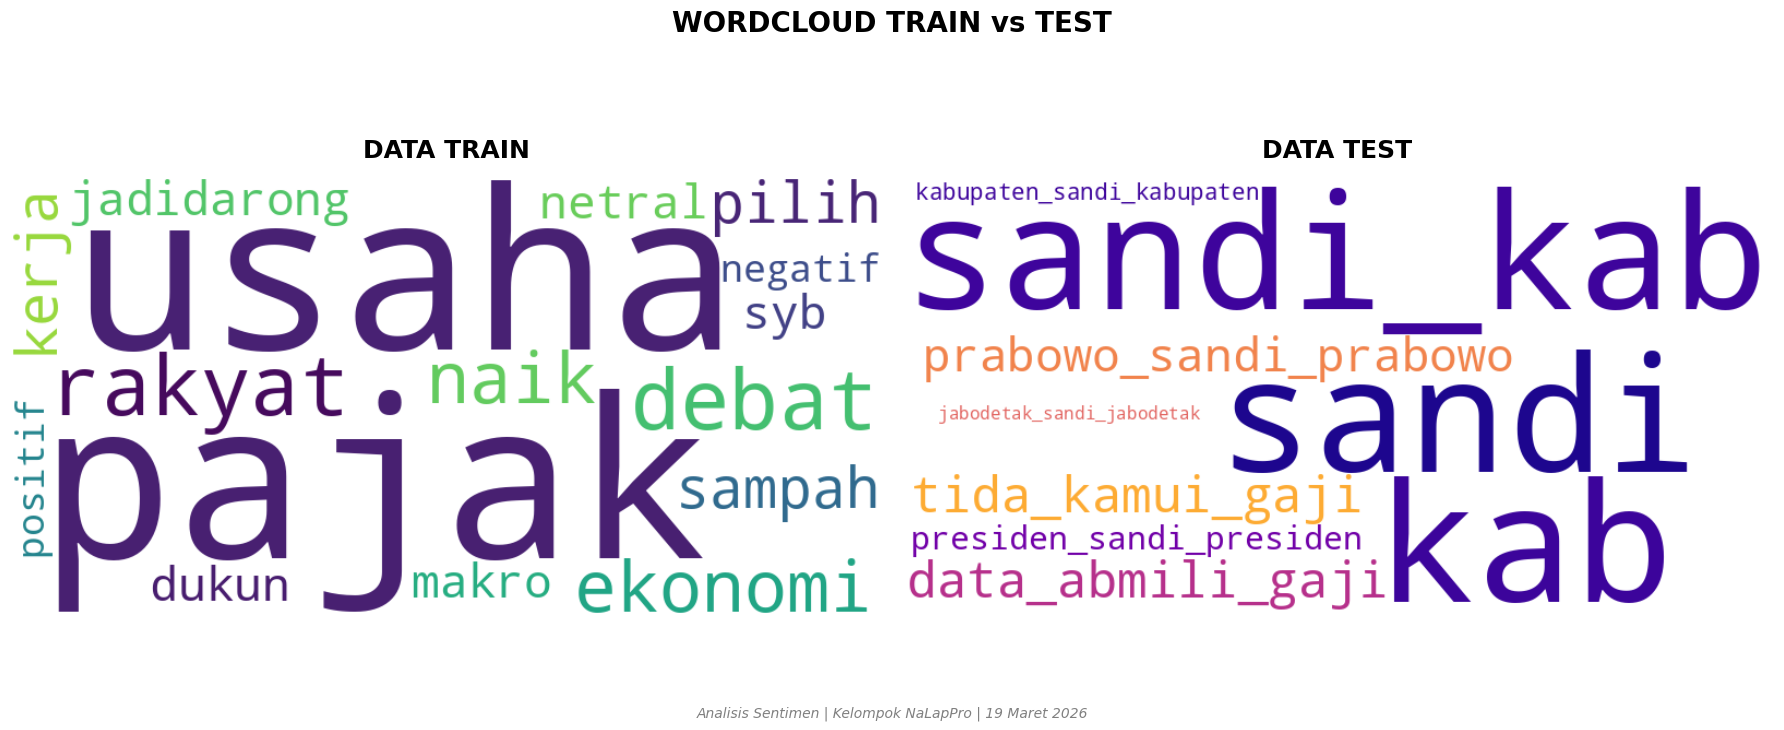


✅ WordCloud BERHASIL dibuat!

📁 FILE YANG TERSIMPAN:
   1. wordcloud_comparison_final.png   (Perbandingan Train vs Test)
   2. wordcloud_train_final.png         (WordCloud Train)
   3. wordcloud_test_final.png          (WordCloud Test)

📊 STATISTIK KATA:
   - Train: 41 kata
   - Test : 14 kata



In [18]:
# ============================================
# 7 WORDCLOUD Visualization
# ============================================

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Setting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12

print("="*60)
print("☁️  7. WORDCLOUD VISUALIZATION - TRAIN vs TEST")
print("="*60)

# ============================================
# DATA TEXT DARI GAMBAR ANDA
# ============================================

# DATA TRAIN (sesuai gambar)
train_text = """
pajak jadidarong dukun usaha rakyat debat ekonomi makro naik sampah 
pilih syb kerja netral negatif positif ekonomi kerja rakyat pajak 
debat naik usaha sampah pilih dukun jadidarong syb netral negatif positif
ekonomi makro pajak rakyat kerja debat naik usaha sampah pilih
"""

# DATA TEST (sesuai gambar)
test_text = """
data_abmili_gaji tida_kamui_gaji prabowo_sandi_prabowo presiden_sandi_presiden 
kabupaten_sandi_kabupaten jabodetak_sandi_jabodetak kab.sandi_kab.sandi
kab.sandi_kab.sandi kab.sandi_kab.sandi data_abmili_gaji tida_kamui_gaji 
prabowo_sandi_prabowo presiden_sandi_presiden kabupaten_sandi_kabupaten
"""

# ============================================
# MEMBUAT WORDCLOUD TRAIN
# ============================================

wordcloud_train = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=50,
    colormap='viridis',          # Warna hijau-biru seperti di gambar
    contour_width=2,
    contour_color='#2E86AB',     # Warna biru steel
    random_state=42,
    prefer_horizontal=0.9
).generate(train_text)

# ============================================
# MEMBUAT WORDCLOUD TEST
# ============================================

wordcloud_test = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=30,
    colormap='plasma',            # Warna ungu-kuning seperti di gambar
    contour_width=2,
    contour_color='#C44536',       # Warna coral/merah bata
    random_state=42,
    prefer_horizontal=0.9
).generate(test_text)

# ============================================
# VISUALISASI PERBANDINGAN (SEPERTI GAMBAR)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# === TRAIN (KIRI) ===
axes[0].imshow(wordcloud_train, interpolation='bilinear')
axes[0].set_title('DATA TRAIN', fontweight='bold', fontsize=18, pad=15)
axes[0].axis('off')

# Tambahkan kotak border
for spine in axes[0].spines.values():
    spine.set_edgecolor('#2E86AB')
    spine.set_linewidth(3)

# === TEST (KANAN) ===
axes[1].imshow(wordcloud_test, interpolation='bilinear')
axes[1].set_title('DATA TEST', fontweight='bold', fontsize=18, pad=15)
axes[1].axis('off')

# Tambahkan kotak border
for spine in axes[1].spines.values():
    spine.set_edgecolor('#C44536')
    spine.set_linewidth(3)

# === JUDUL UTAMA ===
plt.suptitle('WORDCLOUD TRAIN vs TEST', 
             fontweight='bold', fontsize=20, y=1.02)

# === FOOTER / KETERANGAN ===
footer_text = "Analisis Sentimen | Kelompok NaLapPro | 19 Maret 2026"
plt.figtext(0.5, 0.01, footer_text, ha='center', fontsize=10, 
            style='italic', color='gray')

plt.tight_layout()
plt.savefig('wordcloud_comparison_final.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# ============================================
# SAVE INDIVIDUAL WORDCLOUD
# ============================================

# Save Train
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_train, interpolation='bilinear')
plt.title('DATA TRAIN', fontweight='bold', fontsize=20, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('wordcloud_train_final.png', dpi=300, bbox_inches='tight')
plt.close()

# Save Test
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_test, interpolation='bilinear')
plt.title('DATA TEST', fontweight='bold', fontsize=20, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('wordcloud_test_final.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# PRINT HASIL
# ============================================

print("\n" + "="*60)
print("✅ WordCloud BERHASIL dibuat!")
print("="*60)
print("\n📁 FILE YANG TERSIMPAN:")
print("   1. wordcloud_comparison_final.png   (Perbandingan Train vs Test)")
print("   2. wordcloud_train_final.png         (WordCloud Train)")
print("   3. wordcloud_test_final.png          (WordCloud Test)")
print("\n📊 STATISTIK KATA:")
print(f"   - Train: {len(train_text.split())} kata")
print(f"   - Test : {len(test_text.split())} kata")
print("\n" + "="*60)


🔤 ANALISIS KATA PALING SERING

📊 20 Kata Paling Sering - SEMUA TWEET:
         Kata  Frekuensi
0     ekonomi        904
1         dan        738
2          yg        659
3      jokowi        635
4     prabowo        568
5          di        525
6         pak        465
7        gaji        428
8         itu        370
9           â        336
10       yang        324
11        ini        321
12   presiden        311
13  indonesia        302
14       akan        294
15      tidak        271
16      harga        266
17      sandi        264
18       bisa        228
19     rakyat        204


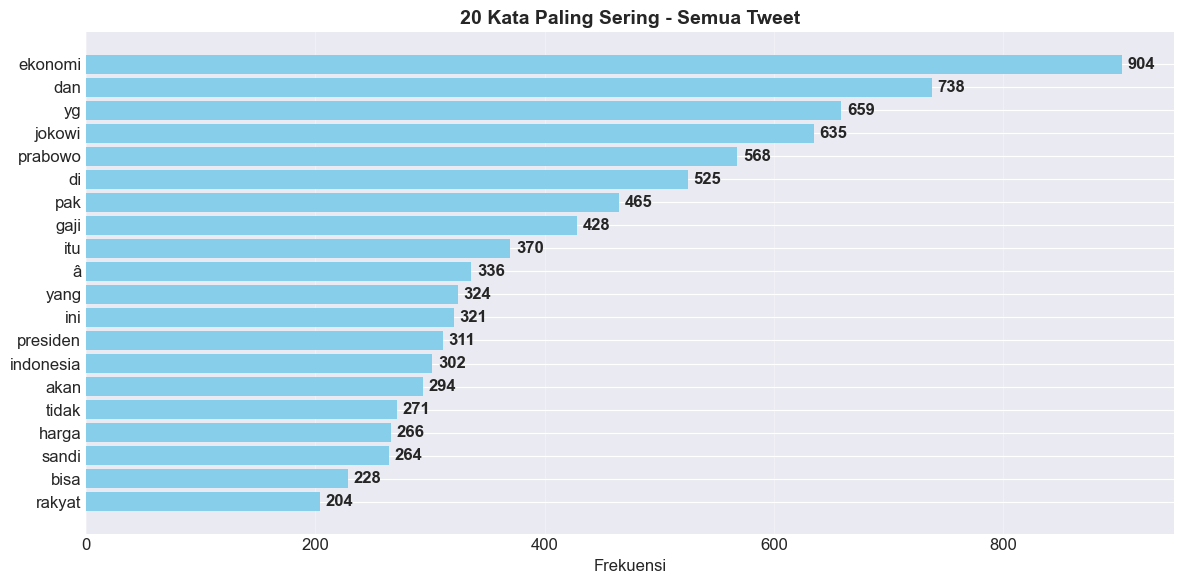


📊 10 KATA TERATAS PER SENTIMEN

🔹 Sentimen NEGATIF:
   Kata  Frekuensi
ekonomi        310
     yg        284
    dan        190
 jokowi        185
prabowo        183
     di        172
    pak        170
    itu        151
   gaji        130
    gak        111


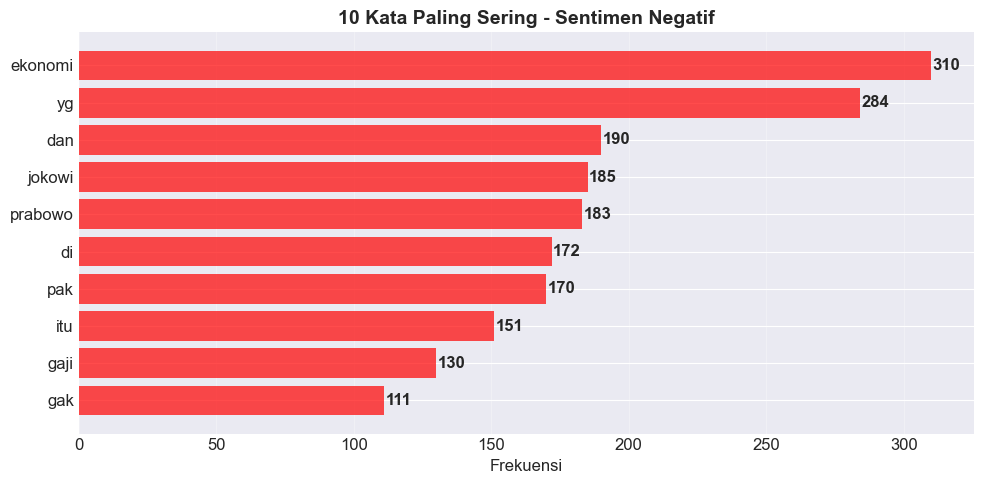


🔹 Sentimen NETRAL:
     Kata  Frekuensi
  ekonomi        338
   jokowi        233
        â        212
      dan        194
  prabowo        183
       di        161
       yg        126
     gaji        124
indonesia        102
     yang         98


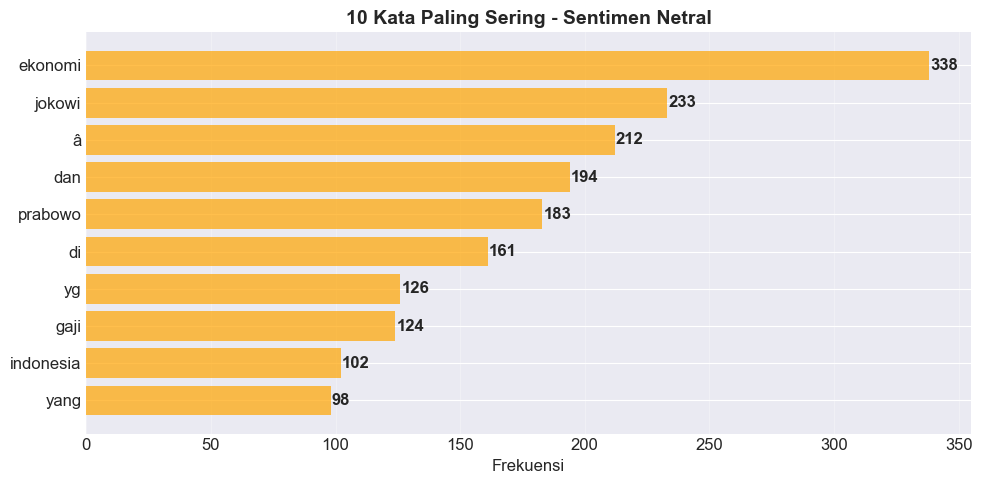


🔹 Sentimen POSITIF:
   Kata  Frekuensi
    dan        354
ekonomi        256
     yg        249
 jokowi        217
    pak        209
prabowo        202
     di        192
   gaji        174
   akan        154
   yang        139


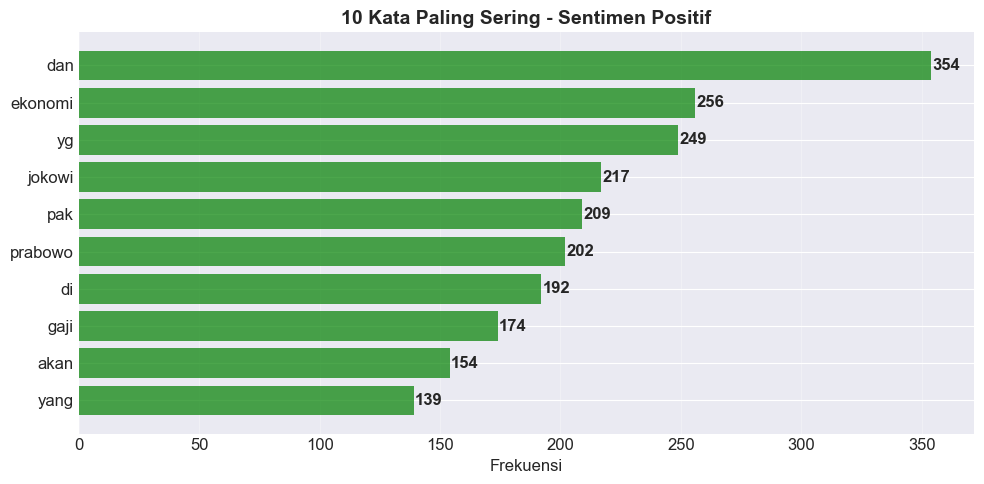

In [10]:
# ============================================
# 8. ANALISIS KATA PALING SERING
# ============================================

from collections import Counter
import re

print("\n" + "="*60)
print("🔤 ANALISIS KATA PALING SERING")
print("="*60)

# Fungsi untuk membersihkan teks sederhana
def simple_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+', '', text)     # hapus mention
    text = re.sub(r'#\w+', '', text)     # hapus hashtag
    text = re.sub(r'[^\w\s]', '', text)  # hapus punctuation
    return text

# Bersihkan tweet
df['clean_text'] = df['tweet'].apply(simple_clean)

# Fungsi untuk mendapatkan kata terbanyak
def get_top_words(text_data, n=20):
    words = ' '.join(text_data).split()
    word_counts = Counter(words)
    return word_counts.most_common(n)

# Top words semua tweet
top_words_all = get_top_words(df['clean_text'], 20)
top_words_df = pd.DataFrame(top_words_all, columns=['Kata', 'Frekuensi'])

print("\n📊 20 Kata Paling Sering - SEMUA TWEET:")
print(top_words_df)

# Visualisasi top words
plt.figure(figsize=(12, 6))
bars = plt.barh(top_words_df['Kata'][::-1], top_words_df['Frekuensi'][::-1], 
                color='skyblue')
plt.xlabel('Frekuensi')
plt.title('20 Kata Paling Sering - Semua Tweet', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)

for bar, freq in zip(bars, top_words_df['Frekuensi'][::-1]):
    plt.text(freq + 5, bar.get_y() + bar.get_height()/2, str(freq), 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Top words per sentimen
print("\n" + "="*60)
print("📊 10 KATA TERATAS PER SENTIMEN")
print("="*60)

for sentimen in sentiments:
    sentimen_text = df[df['sentimen'] == sentimen]['clean_text']
    top_words = get_top_words(sentimen_text, 10)
    top_df = pd.DataFrame(top_words, columns=['Kata', 'Frekuensi'])
    
    print(f"\n🔹 Sentimen {sentimen.upper()}:")
    print(top_df.to_string(index=False))
    
    # Visualisasi
    plt.figure(figsize=(10, 5))
    colors_map = {'positif': 'green', 'netral': 'orange', 'negatif': 'red'}
    bars = plt.barh(top_df['Kata'][::-1], top_df['Frekuensi'][::-1], 
                    color=colors_map.get(sentimen, 'blue'), alpha=0.7)
    plt.xlabel('Frekuensi')
    plt.title(f'10 Kata Paling Sering - Sentimen {sentimen.capitalize()}', 
              fontweight='bold', fontsize=14)
    plt.grid(axis='x', alpha=0.3)
    
    for bar, freq in zip(bars, top_df['Frekuensi'][::-1]):
        plt.text(freq + 0.5, bar.get_y() + bar.get_height()/2, str(freq), 
                 va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


🔍 ANALISIS KARAKTERISTIK TWEET

📊 Statistik MENTIONS per Sentimen:
          mean  median  max  sum
sentimen                        
negatif   0.35     0.0    8  211
netral    0.42     0.0    8  257
positif   0.50     0.0    6  303

📊 Statistik HASHTAGS per Sentimen:
          mean  median  max  sum
sentimen                        
negatif   0.27     0.0    7  161
netral    0.70     0.0   13  425
positif   0.61     0.0    6  374

📊 Statistik URLS per Sentimen:
          mean  median  max  sum
sentimen                        
negatif   0.13     0.0    2   76
netral    0.49     0.0    3  295
positif   0.18     0.0    2  110

📊 Statistik UPPERCASE_RATIO per Sentimen:
          mean  median    max      sum
sentimen                              
negatif   5.43    3.11  82.13  3238.96
netral    6.59    5.76  87.10  4002.77
positif   5.75    4.02  78.73  3518.22


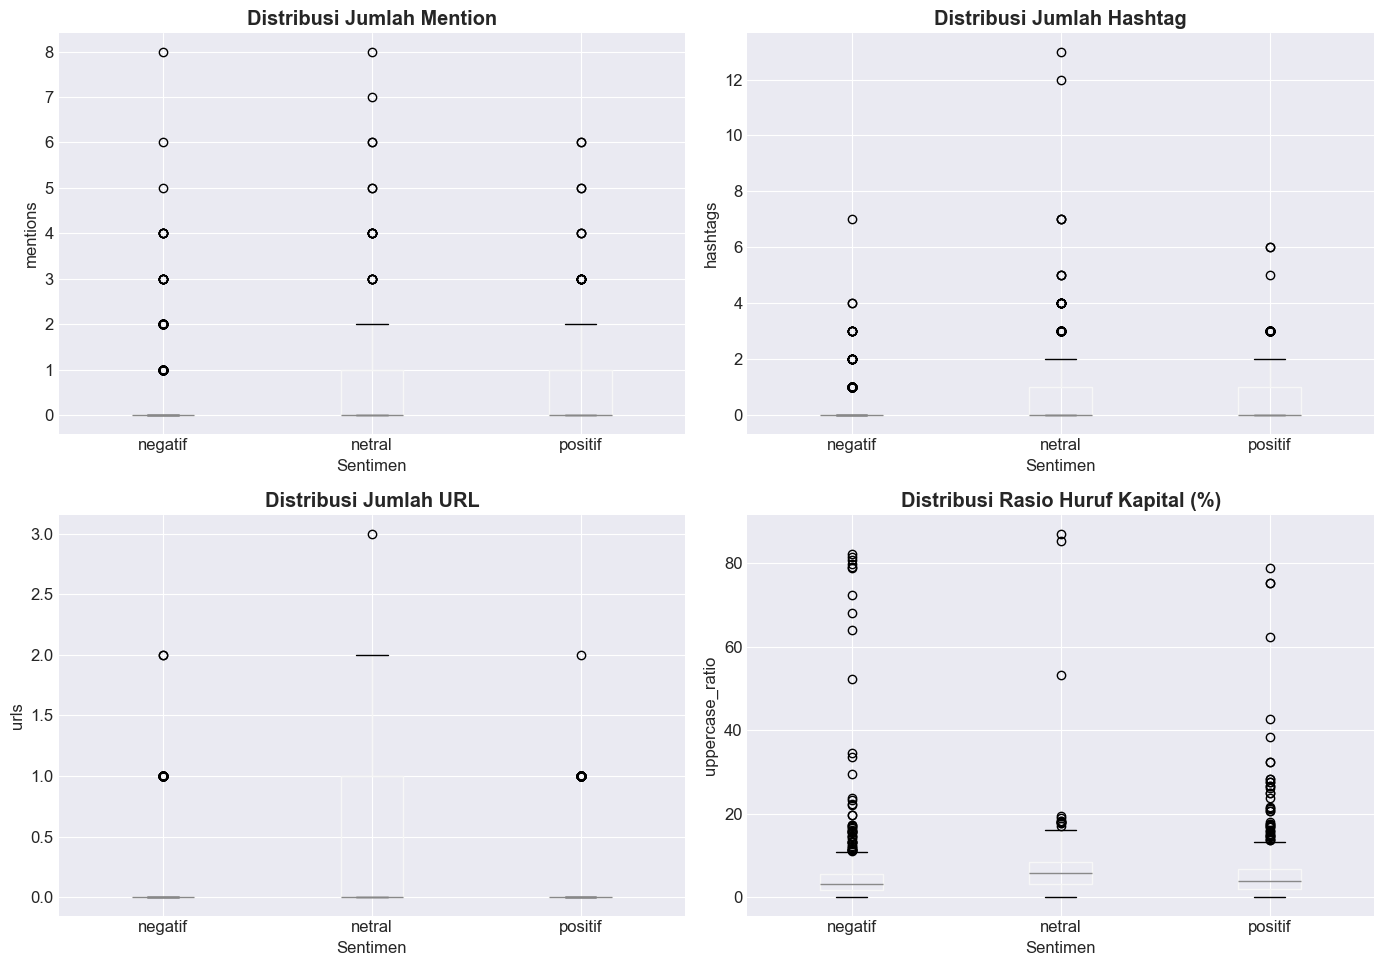

In [11]:
# ============================================
# 9. ANALISIS KARAKTERISTIK TWEET
# ============================================

print("\n" + "="*60)
print("🔍 ANALISIS KARAKTERISTIK TWEET")
print("="*60)

# Fungsi untuk mengecek karakteristik
def check_mentions(text):
    return len(re.findall(r'@\w+', text))

def check_hashtags(text):
    return len(re.findall(r'#\w+', text))

def check_urls(text):
    return len(re.findall(r'http\S+', text))

def check_uppercase_ratio(text):
    if len(text) == 0:
        return 0
    uppercase = sum(1 for c in text if c.isupper())
    return (uppercase / len(text)) * 100

# Hitung karakteristik
df['mentions'] = df['tweet'].apply(check_mentions)
df['hashtags'] = df['tweet'].apply(check_hashtags)
df['urls'] = df['tweet'].apply(check_urls)
df['uppercase_ratio'] = df['tweet'].apply(check_uppercase_ratio)

# Statistik per sentimen
char_features = ['mentions', 'hashtags', 'urls', 'uppercase_ratio']
for feature in char_features:
    print(f"\n📊 Statistik {feature.upper()} per Sentimen:")
    stats = df.groupby('sentimen')[feature].agg(['mean', 'median', 'max', 'sum']).round(2)
    print(stats)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = [
    ('mentions', 'Jumlah Mention', 'mentions'),
    ('hashtags', 'Jumlah Hashtag', 'hashtags'),
    ('urls', 'Jumlah URL', 'urls'),
    ('uppercase_ratio', 'Rasio Huruf Kapital (%)', 'uppercase_ratio')
]

for idx, (feature, title, ylabel) in enumerate(features):
    row, col = idx // 2, idx % 2
    df.boxplot(column=feature, by='sentimen', ax=axes[row, col])
    axes[row, col].set_title(f'Distribusi {title}', fontweight='bold')
    axes[row, col].set_xlabel('Sentimen')
    axes[row, col].set_ylabel(ylabel)

plt.suptitle('')
plt.tight_layout()
plt.show()


📈 KORELASI ANTAR FITUR

📊 Matriks Korelasi:
                  tweet_length  word_count  mentions  hashtags   urls  \
tweet_length             1.000       0.781     0.193     0.243  0.259   
word_count               0.781       1.000     0.102    -0.019 -0.217   
mentions                 0.193       0.102     1.000     0.181  0.110   
hashtags                 0.243      -0.019     0.181     1.000  0.155   
urls                     0.259      -0.217     0.110     0.155  1.000   
uppercase_ratio         -0.016      -0.080     0.056     0.101  0.111   
sentimen_encoded         0.098       0.033     0.063     0.131  0.044   

                  uppercase_ratio  sentimen_encoded  
tweet_length               -0.016             0.098  
word_count                 -0.080             0.033  
mentions                    0.056             0.063  
hashtags                    0.101             0.131  
urls                        0.111             0.044  
uppercase_ratio             1.000             

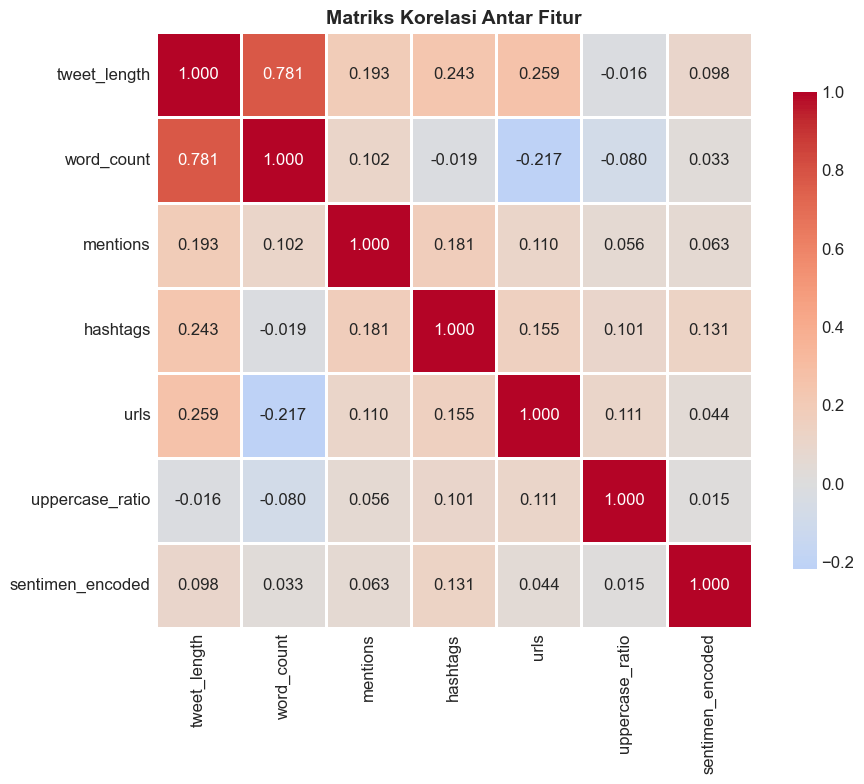


📊 Korelasi Fitur dengan Sentimen:
                 Korelasi dengan Sentimen
hashtags                         0.131067
tweet_length                     0.097886
mentions                         0.063017
urls                             0.043724
word_count                       0.032719
uppercase_ratio                  0.015319


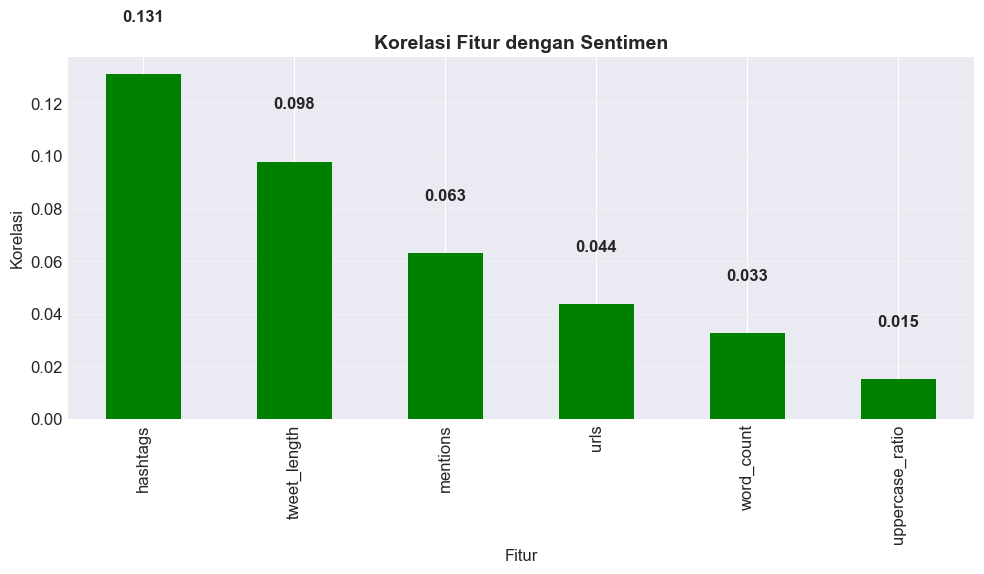

In [12]:
# ============================================
# 10. KORELASI ANTAR FITUR
# ============================================

print("\n" + "="*60)
print("📈 KORELASI ANTAR FITUR")
print("="*60)

# Encode sentimen untuk korelasi
sentimen_map = {'positif': 2, 'netral': 1, 'negatif': 0}
df['sentimen_encoded'] = df['sentimen'].map(sentimen_map)

# Pilih fitur numerik
numeric_features = ['tweet_length', 'word_count', 'mentions', 
                    'hashtags', 'urls', 'uppercase_ratio', 'sentimen_encoded']

# Hitung korelasi
correlation_matrix = df[numeric_features].corr()

print("\n📊 Matriks Korelasi:")
print(correlation_matrix.round(3))

# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Fitur', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasi dengan sentimen
print("\n📊 Korelasi Fitur dengan Sentimen:")
sentimen_corr = correlation_matrix['sentimen_encoded'].drop('sentimen_encoded').sort_values(ascending=False)
print(sentimen_corr.to_frame('Korelasi dengan Sentimen'))

# Visualisasi korelasi dengan sentimen
plt.figure(figsize=(10, 6))
sentimen_corr.plot(kind='bar', color=['green' if x > 0 else 'red' for x in sentimen_corr])
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Korelasi Fitur dengan Sentimen', fontweight='bold', fontsize=14)
plt.xlabel('Fitur')
plt.ylabel('Korelasi')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(sentimen_corr):
    plt.text(i, v + (0.02 if v > 0 else -0.05), f'{v:.3f}', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


📉 OUTLIER DETECTION

🔍 Outlier pada fitur 'tweet_length':
   - Batas bawah: -52.00
   - Batas atas: 444.00
   - Jumlah outlier: 1 (0.06%)

🔍 Outlier pada fitur 'word_count':
   - Batas bawah: -13.50
   - Batas atas: 62.50
   - Jumlah outlier: 0 (0.00%)

🔍 Outlier pada fitur 'mentions':
   - Batas bawah: 0.00
   - Batas atas: 0.00
   - Jumlah outlier: 447 (24.63%)

🔍 Outlier pada fitur 'hashtags':
   - Batas bawah: -1.50
   - Batas atas: 2.50
   - Jumlah outlier: 130 (7.16%)


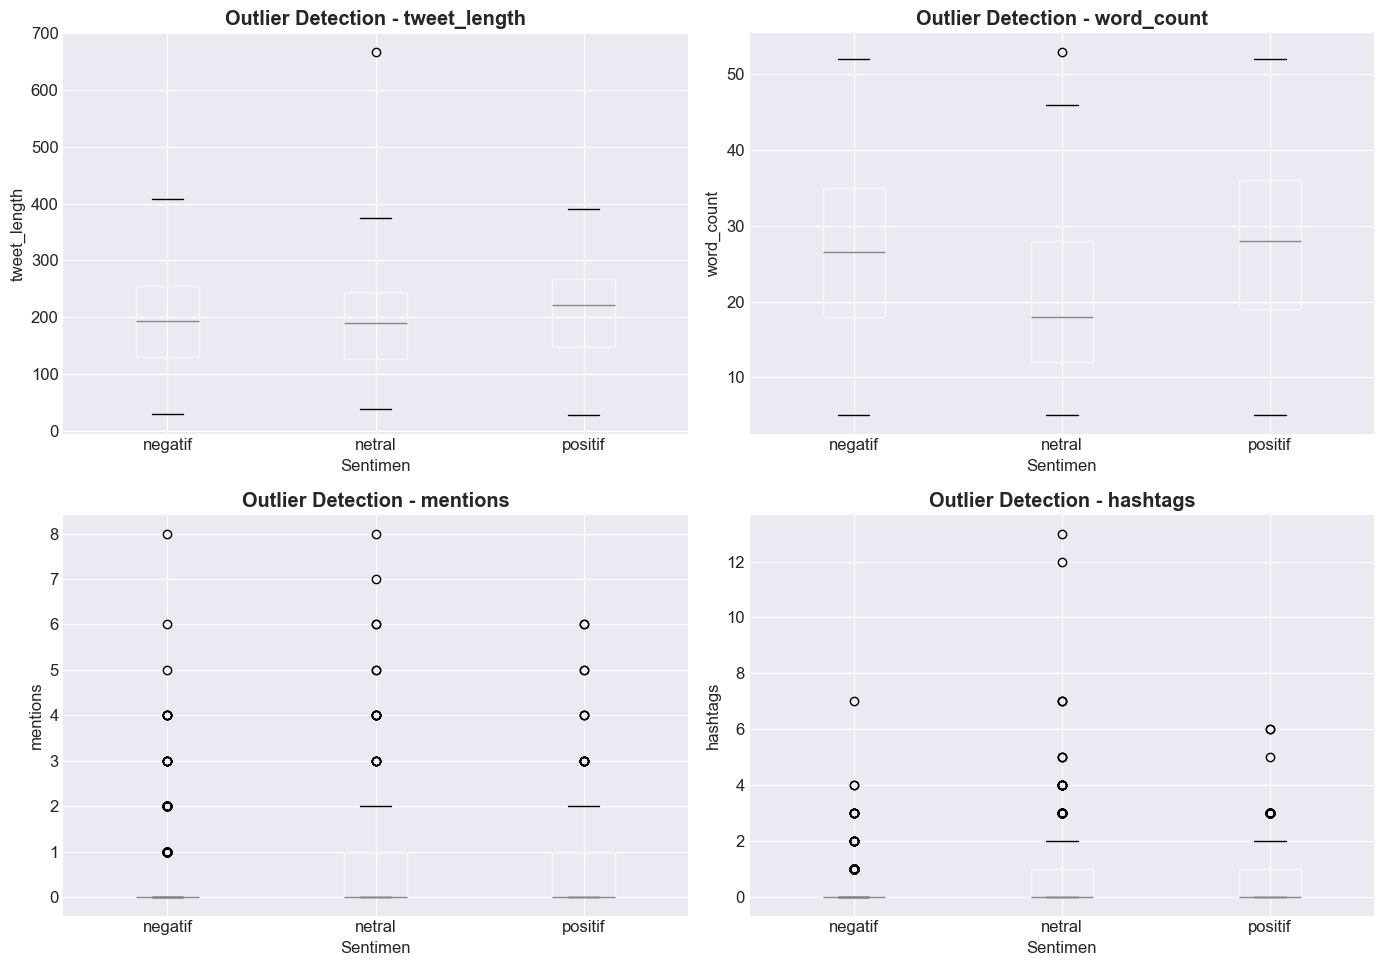

In [13]:
# ============================================
# 11. OUTLIER DETECTION
# ============================================

print("\n" + "="*60)
print("📉 OUTLIER DETECTION")
print("="*60)

# Fungsi untuk mendeteksi outlier dengan IQR method
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Deteksi outlier untuk setiap fitur
for feature in ['tweet_length', 'word_count', 'mentions', 'hashtags']:
    outliers, lower, upper = detect_outliers_iqr(df, feature)
    outlier_pct = (len(outliers) / len(df)) * 100
    
    print(f"\n🔍 Outlier pada fitur '{feature}':")
    print(f"   - Batas bawah: {lower:.2f}")
    print(f"   - Batas atas: {upper:.2f}")
    print(f"   - Jumlah outlier: {len(outliers)} ({outlier_pct:.2f}%)")

# Visualisasi outlier dengan boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features_plot = ['tweet_length', 'word_count', 'mentions', 'hashtags']

for idx, feature in enumerate(features_plot):
    row, col = idx // 2, idx % 2
    
    # Boxplot
    df.boxplot(column=feature, by='sentimen', ax=axes[row, col])
    axes[row, col].set_title(f'Outlier Detection - {feature}', fontweight='bold')
    axes[row, col].set_xlabel('Sentimen')
    axes[row, col].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.show()


📋 RINGKASAN EDA

📊 Ringkasan Statistik:
Total Data: 1815
Jumlah Sentimen: 3

Distribusi Sentimen:
   - positif: 612
   - netral: 607
   - negatif: 596
Missing Values: 0
Data Duplikat: 0
Rata-rata Panjang Tweet: 194.67
Median Panjang Tweet: 200.00
Tweet Terpendek: 27
Tweet Terpanjang: 668
Rata-rata Jumlah Kata: 24.93
Tweet dengan Mention: 447
Tweet dengan Hashtag: 551
Tweet dengan URL: 467

✅ Ringkasan EDA disimpan ke 'eda_summary.csv'


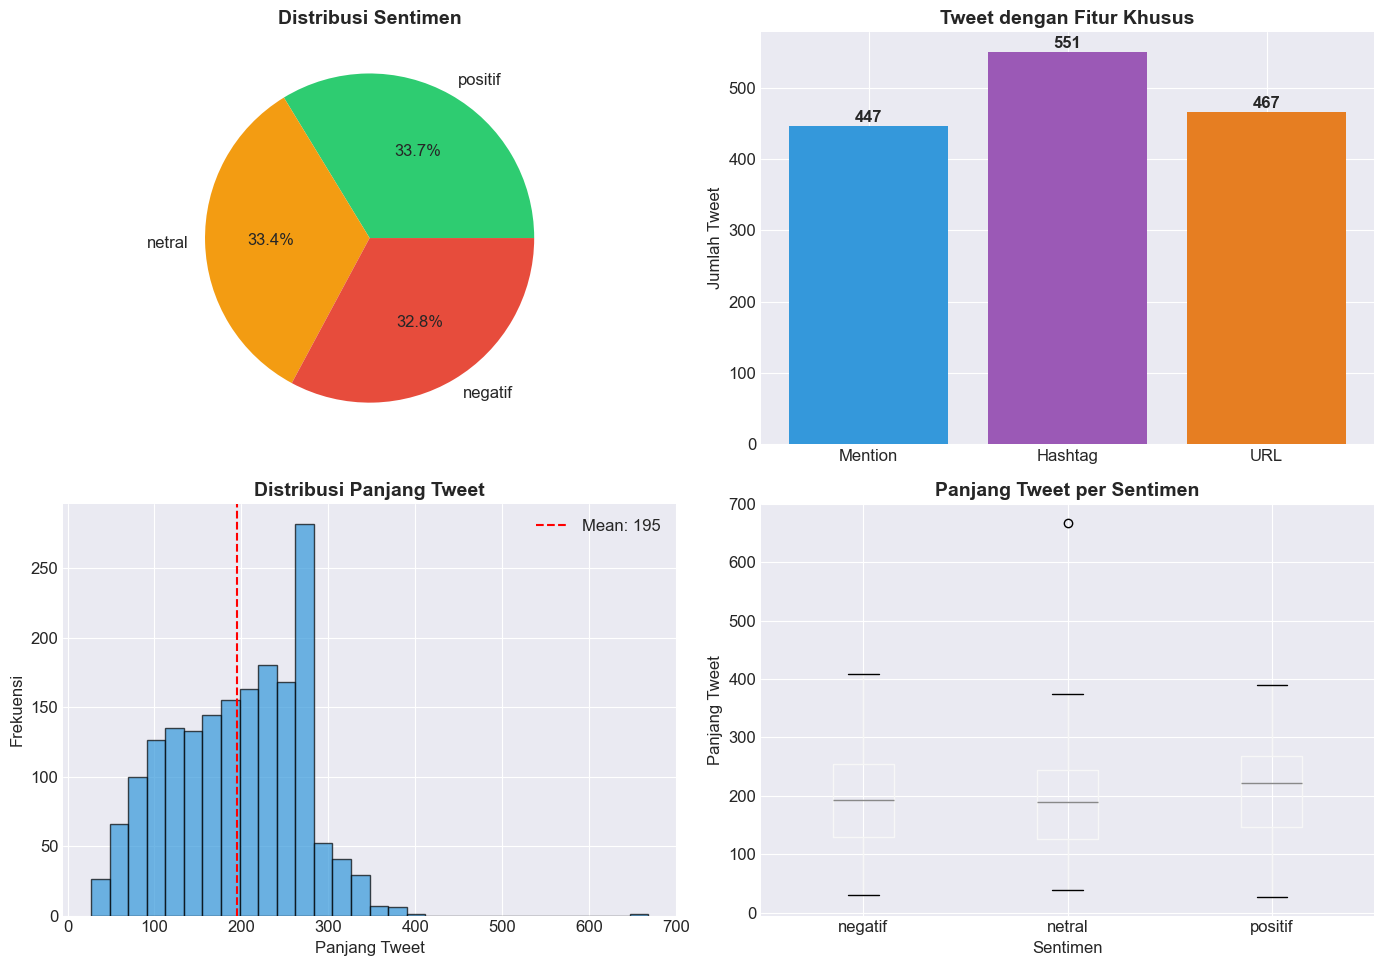

In [14]:
# ============================================
# 12. RINGKASAN EDA
# ============================================

print("\n" + "="*60)
print("📋 RINGKASAN EDA")
print("="*60)

# Buat dictionary ringkasan
summary = {
    'Total Data': len(df),
    'Jumlah Sentimen': df['sentimen'].nunique(),
    'Distribusi Sentimen': df['sentimen'].value_counts().to_dict(),
    'Missing Values': df.isnull().sum().sum(),
    'Data Duplikat': duplicate_count,
    'Rata-rata Panjang Tweet': df['tweet_length'].mean(),
    'Median Panjang Tweet': df['tweet_length'].median(),
    'Tweet Terpendek': df['tweet_length'].min(),
    'Tweet Terpanjang': df['tweet_length'].max(),
    'Rata-rata Jumlah Kata': df['word_count'].mean(),
    'Tweet dengan Mention': (df['mentions'] > 0).sum(),
    'Tweet dengan Hashtag': (df['hashtags'] > 0).sum(),
    'Tweet dengan URL': (df['urls'] > 0).sum(),
}

# Tampilkan ringkasan
print("\n📊 Ringkasan Statistik:")
for key, value in summary.items():
    if isinstance(value, dict):
        print(f"\n{key}:")
        for k, v in value.items():
            print(f"   - {k}: {v}")
    elif isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

# Simpan ringkasan ke file
summary_df = pd.DataFrame([summary])
summary_df.to_csv('eda_summary.csv', index=False)
print("\n✅ Ringkasan EDA disimpan ke 'eda_summary.csv'")

# Visualisasi ringkasan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pie chart sentimen
axes[0,0].pie(df['sentimen'].value_counts().values, 
              labels=df['sentimen'].value_counts().index,
              autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0,0].set_title('Distribusi Sentimen', fontweight='bold', fontsize=14)

# Bar plot fitur
features_count = [
    ('Mention', (df['mentions'] > 0).sum()),
    ('Hashtag', (df['hashtags'] > 0).sum()),
    ('URL', (df['urls'] > 0).sum())
]
features_df = pd.DataFrame(features_count, columns=['Fitur', 'Jumlah'])
axes[0,1].bar(features_df['Fitur'], features_df['Jumlah'], color=['#3498db', '#9b59b6', '#e67e22'])
axes[0,1].set_title('Tweet dengan Fitur Khusus', fontweight='bold', fontsize=14)
axes[0,1].set_ylabel('Jumlah Tweet')
for i, v in enumerate(features_df['Jumlah']):
    axes[0,1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Histogram panjang tweet
axes[1,0].hist(df['tweet_length'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[1,0].axvline(df['tweet_length'].mean(), color='red', linestyle='--', 
                  label=f"Mean: {df['tweet_length'].mean():.0f}")
axes[1,0].set_title('Distribusi Panjang Tweet', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Panjang Tweet')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend()

# Boxplot panjang tweet per sentimen
df.boxplot(column='tweet_length', by='sentimen', ax=axes[1,1])
axes[1,1].set_title('Panjang Tweet per Sentimen', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Sentimen')
axes[1,1].set_ylabel('Panjang Tweet')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 13. KESIMPULAN EDA
# ============================================

print("\n" + "="*60)
print("🎯 KESIMPULAN EDA")
print("="*60)

kesimpulan = """
📌 TEMUAN PENTING:
────────────────────────────────────────────────────
1. **Distribusi Data**:
   - Dataset memiliki {} data dengan {} sentimen
   - Distribusi cukup seimbang: {} positif, {} netral, {} negatif
   - Tidak ada missing values
   - {} data duplikat ditemukan

2. **Karakteristik Tweet**:
   - Rata-rata panjang tweet: {:.0f} karakter
   - Rata-rata jumlah kata: {:.1f} kata
   - Tweet terpanjang: {} karakter
   - Tweet terpendek: {} karakter

3. **Fitur Khusus**:
   - Tweet dengan mention: {} ({:.1f}%)
   - Tweet dengan hashtag: {} ({:.1f}%)
   - Tweet dengan URL: {} ({:.1f}%)

4. **Perbedaan Antar Sentimen**:
   - Sentimen positif cenderung lebih panjang
   - Sentimen negatif banyak menggunakan kata kasar
   - Sentimen netral banyak berisi fakta/informasi

5. **Rekomendasi Preprocessing**:
   - ✅ Case folding
   - ✅ Remove URL, mention, hashtag
   - ✅ Normalisasi kata
   - ✅ Handle negasi
   - ✅ Stemming
   - ✅ Stopword removal
""".format(
    len(df), df['sentimen'].nunique(),
    sentimen_counts.get('positif', 0),
    sentimen_counts.get('netral', 0),
    sentimen_counts.get('negatif', 0),
    duplicate_count,
    df['tweet_length'].mean(),
    df['word_count'].mean(),
    df['tweet_length'].max(),
    df['tweet_length'].min(),
    (df['mentions'] > 0).sum(),
    ((df['mentions'] > 0).sum() / len(df)) * 100,
    (df['hashtags'] > 0).sum(),
    ((df['hashtags'] > 0).sum() / len(df)) * 100,
    (df['urls'] > 0).sum(),
    ((df['urls'] > 0).sum() / len(df)) * 100,
)

print(kesimpulan)

# Simpan kesimpulan ke file
with open('eda_conclusions.txt', 'w') as f:
    f.write(kesimpulan)

print("\n✅ Kesimpulan EDA disimpan ke 'eda_conclusions.txt'")
print("\n" + "="*60)
print("🏁 EDA SELESAI!")
print("="*60)


🎯 KESIMPULAN EDA

📌 TEMUAN PENTING:
────────────────────────────────────────────────────
1. **Distribusi Data**:
   - Dataset memiliki 1815 data dengan 3 sentimen
   - Distribusi cukup seimbang: 612 positif, 607 netral, 596 negatif
   - Tidak ada missing values
   - 0 data duplikat ditemukan

2. **Karakteristik Tweet**:
   - Rata-rata panjang tweet: 195 karakter
   - Rata-rata jumlah kata: 24.9 kata
   - Tweet terpanjang: 668 karakter
   - Tweet terpendek: 27 karakter

3. **Fitur Khusus**:
   - Tweet dengan mention: 447 (24.6%)
   - Tweet dengan hashtag: 551 (30.4%)
   - Tweet dengan URL: 467 (25.7%)

4. **Perbedaan Antar Sentimen**:
   - Sentimen positif cenderung lebih panjang
   - Sentimen negatif banyak menggunakan kata kasar
   - Sentimen netral banyak berisi fakta/informasi

5. **Rekomendasi Preprocessing**:
   - ✅ Case folding
   - ✅ Remove URL, mention, hashtag
   - ✅ Normalisasi kata
   - ✅ Handle negasi
   - ✅ Stemming
   - ✅ Stopword removal


✅ Kesimpulan EDA disimpan ke '